# IMPORTS

In [1]:
import os
import pandas as pd
import numpy as np
import re
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.utils import shuffle
import eli5
from eli5.sklearn import PermutationImportance
from eli5 import show_weights, show_prediction

# CONFIGURAÇÕES

In [2]:
BASE_FOLDER_TRAIN = "treino"

TRAIN_FILE = "ep2-train.csv"

preprocess_params = {
    "lowercase": False,
    "normalize_unicode": False,
    "remove_extra_whitespace": False,
    "remove_punct": False,
    
    "normalize_email": True,
    "normalize_url": True,
    "normalize_phone": True,
    "normalize_date": True,
    "normalize_time": True,
    "normalize_percent": True,
    "normalize_document": True,
    "normalize_code": True,
    "normalize_law": True,
}

In [3]:
# Configuração do Baseline (parâmetros fixos)
BASELINE_CONFIG = {
    'vectorizer': {
        'max_features': 10000,
        'ngram_range': (1, 2)
    },
    'model': {
        'C': 1.0,
        'solver': 'lbfgs',
        'class_weight': None,
        'max_iter': 1000,
        'random_state': 42
    }
}


# ANÁLISE DE BALANCEAMENTO DOS DATASETS


In [4]:
def analisar_balanceamento(file_name):
    """Função para analisar o balanceamento de um dataset"""
    path = os.path.join(BASE_FOLDER_TRAIN, file_name)
    df = pd.read_csv(path, sep=";", encoding="latin1")
    
    print("="*60)
    print(f"ANÁLISE ESTATÍSTICA - {file_name}")
    print("="*60)
    
    # Informações básicas
    print(f"\n📊 INFORMAÇÕES GERAIS:")
    print(f"   • Total de linhas: {len(df):,}")
    print(f"   • Total de colunas: {len(df.columns)}")
    print(f"   • Colunas: {list(df.columns)}")
    
    # Verificar valores nulos
    print(f"\n🔍 VALORES NULOS:")
    print(f"   • Coluna 'req_text': {df['req_text'].isna().sum()}")
    print(f"   • Coluna 'profession': {df['profession'].isna().sum()}")
    
    # Distribuição das classes
    print(f"\n📈 DISTRIBUIÇÃO DAS CLASSES:")
    contagem_classes = df['profession'].value_counts()
    print(contagem_classes)
    
    print(f"\n📊 PORCENTAGEM POR CLASSE:")
    porcentagem_classes = df['profession'].value_counts(normalize=True) * 100
    for classe, perc in porcentagem_classes.items():
        count = contagem_classes[classe]
        print(f"   • {classe}: {count:,} ({perc:.2f}%)")
    
    # Verificar balanceamento
    print(f"\n⚖️ BALANCEAMENTO:")
    razao = contagem_classes.max() / contagem_classes.min()
    print(f"   • Razão maior/menor classe: {razao:.2f}x")
    if razao < 1.5:
        print(f"   • Status: ✅ Dataset bem balanceado")
    elif razao < 3:
        print(f"   • Status: ⚠️ Dataset moderadamente desbalanceado")
    else:
        print(f"   • Status: ❌ Dataset desbalanceado")
    
    print("\n" + "="*60)
    print()
    
    return df, contagem_classes


In [5]:
resultados_analise = {}

df, contagem = analisar_balanceamento(TRAIN_FILE)
resultados_analise[TRAIN_FILE] = {
    'dataframe': df,
    'contagem_classes': contagem
}


ANÁLISE ESTATÍSTICA - ep2-train.csv

📊 INFORMAÇÕES GERAIS:
   • Total de linhas: 43,678
   • Total de colunas: 2
   • Colunas: ['req_text', 'profession']

🔍 VALORES NULOS:
   • Coluna 'req_text': 0
   • Coluna 'profession': 0

📈 DISTRIBUIÇÃO DAS CLASSES:
profession
government    18782
academic      14593
private       10303
Name: count, dtype: int64

📊 PORCENTAGEM POR CLASSE:
   • government: 18,782 (43.00%)
   • academic: 14,593 (33.41%)
   • private: 10,303 (23.59%)

⚖️ BALANCEAMENTO:
   • Razão maior/menor classe: 1.82x
   • Status: ⚠️ Dataset moderadamente desbalanceado




# PRÉ-PROCESSAMENTO

In [6]:
def normalize_entities(text, params):
    """
    Normaliza entidades específicas no texto, substituindo por tokens especiais.
    Ordem de aplicação é importante para evitar conflitos!
    """
    if not isinstance(text, str):
        return ""
    
    # 1. EMAIL - Captura endereços de email
    if params.get("normalize_email", False):
        text = re.sub(
            r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b',
            '<EMAIL>',
            text
        )
    
    # 2. URL - Links HTTP/HTTPS e www (MUITO MAIS ROBUSTO)
    if params.get("normalize_url", False):
        # URLs com protocolo (http, https, ftp) - SEM \b para evitar problemas
        # Captura até encontrar espaço, aspas, ou pontuação de fim de frase
        text = re.sub(
            r'(?:https?|ftp)://[^\s\)"<>]+',
            '<URL>',
            text,
            flags=re.IGNORECASE
        )
        # URLs começando com www (incluindo www2, www3, etc)
        text = re.sub(
            r'www\d*\.[^\s\)"<>]+',
            '<URL>',
            text,
            flags=re.IGNORECASE
        )
        # Domínios com caminho explícito
        text = re.sub(
            r'[a-z0-9][-a-z0-9]*\.[a-z]{2,}(?:\.[a-z]{2,})?/[^\s\)"<>]+',
            '<URL>',
            text,
            flags=re.IGNORECASE
        )
    
    # 3. PHONE - Telefones brasileiros
    if params.get("normalize_phone", False):
        # Formato: (85) 9 8645.1524, (85) 98645-1524, 85 98645-1524, etc
        text = re.sub(
            r'\(?\d{2}\)?\s?\d{4,5}[-.\s]?\d{4}',
            '<PHONE>',
            text
        )
    
    # 4. DATE - Várias formatações de data
    if params.get("normalize_date", False):
        # DD/MM/YYYY, DD-MM-YYYY, DD.MM.YYYY
        text = re.sub(
            r'\b\d{1,2}[/.-]\d{1,2}[/.-]\d{2,4}\b',
            '<DATE>',
            text
        )
        # YYYY/MM/DD, YYYY-MM-DD
        text = re.sub(
            r'\b\d{4}[/.-]\d{1,2}[/.-]\d{1,2}\b',
            '<DATE>',
            text
        )
    
    # 5. TIME - Horários (CORRIGIDO)
    if params.get("normalize_time", False):
        # Formato HH:MM ou HH:MM:SS
        text = re.sub(
            r'\b\d{1,2}:\d{2}(?::\d{2})?\b',
            '<TIME>',
            text
        )
        # Formato HHhMM (ex: 14h30)
        text = re.sub(
            r'\b\d{1,2}h\d{2}\b',
            '<TIME>',
            text
        )
    
    # 6. PERCENT - Porcentagens
    if params.get("normalize_percent", False):
        text = re.sub(
            r'\b\d+(?:[.,]\d+)?%',
            '<PERCENT>',
            text
        )
    
    # 7. DOCUMENT - CPF e CNPJ
    if params.get("normalize_document", False):
        # CPF: 123.456.789-00
        text = re.sub(
            r'\b\d{3}\.\d{3}\.\d{3}-\d{2}\b',
            '<DOCUMENT>',
            text
        )
        # CNPJ: 12.345.678/0001-00
        text = re.sub(
            r'\b\d{2}\.\d{3}\.\d{3}/\d{4}-\d{2}\b',
            '<DOCUMENT>',
            text
        )
    
    # 8. CODE - Códigos de rastreamento e processos
    if params.get("normalize_code", False):
        # Códigos de rastreamento (ex: RU101805325NL, PG326875631BR)
        text = re.sub(
            r'\b[A-Z]{2}\d{9,}[A-Z]{2}\b',
            '<CODE>',
            text
        )
        # Códigos de processo (ex: AC-2000-08012-000640, DAE 07.16.17365.94815-1)
        text = re.sub(
            r'\b[A-Z]{2,}-?\d{4}-\d{5}-\d{5,6}(?:-\d)?\b',
            '<CODE>',
            text
        )
        # DAE com pontos
        text = re.sub(
            r'\b\d{2}\.\d{2}\.\d{5}\.\d{5}-\d\b',
            '<CODE>',
            text
        )
    
    # 9. LAW - Referências legais
    if params.get("normalize_law", False):
        text = re.sub(
            r'\b(?:Lei|Portaria|Decreto|Resolução|Edital)\s+n[ºo°]?\s*\d+(?:/\d{4})?\b',
            '<LAW>',
            text,
            flags=re.IGNORECASE
        )
    
    return text


In [7]:
def preprocess_operations(text, params):
    """
    Aplica operações de pré-processamento no texto.
    ORDEM IMPORTANTE: Normalização de entidades ANTES de lowercase e remoção de pontuação!
    
    Melhorias:
    - Validação de entrada mais robusta
    - Tratamento de casos especiais
    - Preservação de tokens especiais
    """
    # Validação de entrada
    if not isinstance(text, str):
        return ""
    
    if len(text.strip()) == 0:
        return ""
    
    # PASSO 1: Normalização de entidades (PRIMEIRO - antes de alterar case ou pontuação)
    text = normalize_entities(text, params)
    
    # PASSO 2: Normalização Unicode
    if params.get("normalize_unicode", False):
        text = unicodedata.normalize("NFKC", text)
    
    # PASSO 3: Lowercase
    if params.get("lowercase", False):
        text = text.lower()
    
    # PASSO 4: Remover pontuação (mas preservar tokens especiais <...>)
    if params.get("remove_punct", False):
        # Proteger tokens especiais temporariamente (padrão melhorado)
        text = re.sub(r'<(\w+)>', r'__TOKEN__\1__TOKEN__', text)
        # Remover pontuação (mas manter espaços e alfanuméricos)
        text = re.sub(r"[^\w\s]", " ", text)
        # Restaurar tokens especiais
        text = re.sub(r'__TOKEN__(\w+)__TOKEN__', r'<\1>', text)
    
    # PASSO 5: Remover espaços extras
    if params.get("remove_extra_whitespace", False):
        # Remover múltiplos espaços
        text = re.sub(r"\s+", " ", text)
        # Remover espaços no início e fim
        text = text.strip()
    
    # PASSO 6: Validação final
    if len(text.strip()) == 0:
        return ""
    
    return text

def preprocess_data(path, output_path, params):
    """
    Processa dados, salva no CSV e retorna dados preparados para treinamento.
    
    Melhorias:
    - Validação de dados mais robusta
    - Tratamento de erros
    - Logging de progresso
    - Validação de qualidade dos dados processados
    """
    col_text, col_label = "req_text", "profession"
    
    print("="*80)
    print("PRÉ-PROCESSAMENTO DE DADOS")
    print("="*80)
    
    # 1. Carregar dados originais
    if not os.path.exists(path):
        print(f"❌ Erro: {path} não encontrado.")
        return None
    
    print(f"\n📂 Carregando dados de: {path}")
    df = pd.read_csv(path, sep=";", encoding="latin1")
    print(f"   • Total de linhas carregadas: {len(df):,}")
    
    # 2. Validação inicial
    if col_text not in df.columns or col_label not in df.columns:
        print(f"❌ Erro: Colunas esperadas não encontradas.")
        print(f"   Colunas disponíveis: {list(df.columns)}")
        return None
    
    # 3. Limpeza inicial
    print(f"\n🧹 Limpando dados...")
    initial_count = len(df)
    
    # Remover linhas com valores nulos
    df = df[[col_text, col_label]].dropna()
    after_dropna = len(df)
    
    if initial_count != after_dropna:
        print(f"   • Removidas {initial_count - after_dropna} linhas com valores nulos")
    
    # Remover linhas com texto vazio
    df = df[df[col_text].astype(str).str.strip().str.len() > 0]
    after_empty = len(df)
    
    if after_dropna != after_empty:
        print(f"   • Removidas {after_dropna - after_empty} linhas com texto vazio")
    
    print(f"   • Total de linhas válidas: {len(df):,}")
    
    # 4. Aplicar pré-processamento
    print(f"\n⚙️  Aplicando pré-processamento...")
    print(f"   • Parâmetros ativos:")
    active_params = [k for k, v in params.items() if v]
    if active_params:
        for param in active_params:
            print(f"     - {param}")
    else:
        print(f"     (nenhum parâmetro de pré-processamento ativo)")
    
    # Processar com tratamento de erros
    processed_texts = []
    errors = 0
    
    for idx, text in enumerate(df[col_text]):
        try:
            processed = preprocess_operations(str(text), params)
            processed_texts.append(processed)
        except Exception as e:
            # Em caso de erro, usar texto vazio
            processed_texts.append("")
            errors += 1
        
        # Mostrar progresso a cada 10%
        if len(df) > 10 and (idx + 1) % (len(df) // 10) == 0:
            progress = ((idx + 1) / len(df)) * 100
            print(f"   • Progresso: {progress:.0f}%")
    
    if errors > 0:
        print(f"   ⚠️  Total de erros durante processamento: {errors}")
    
    df['req_text'] = processed_texts
    
    # 5. Validação pós-processamento
    print(f"\n✅ Validando dados processados...")
    
    # Remover linhas que ficaram vazias após processamento
    before_validation = len(df)
    df = df[df['req_text'].str.strip().str.len() > 0]
    after_validation = len(df)
    
    if before_validation != after_validation:
        print(f"   • Removidas {before_validation - after_validation} linhas vazias após processamento")
    
    # Estatísticas dos textos processados
    text_lengths = df['req_text'].str.len()
    print(f"   • Comprimento médio do texto: {text_lengths.mean():.1f} caracteres")
    print(f"   • Comprimento mínimo: {text_lengths.min()} caracteres")
    print(f"   • Comprimento máximo: {text_lengths.max()} caracteres")
    
    # 6. Manter apenas texto processado e profissão
    df_processed = df[['req_text', col_label]].copy()
    
    # 7. Salvar no CSV
    print(f"\n💾 Salvando dados processados...")
    df_processed.to_csv(output_path, sep=";", encoding="utf-8", index=False)
    print(f"   ✅ Arquivo salvo: {output_path}")
    print(f"   • Total de linhas salvas: {len(df_processed):,}")
    
    # 8. Preparar para treinamento
    print(f"\n🔄 Preparando dados para treinamento...")
    
    # Shuffle
    df_processed = shuffle(df_processed, random_state=10).reset_index(drop=True)
    
    # Label Encoding
    le = LabelEncoder()
    y = le.fit_transform(df_processed[col_label])
    
    # Mapeamento de labels (para referência)
    label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"   • Mapeamento de classes: {label_mapping}")
    
    # Distribuição de classes
    class_dist = pd.Series(y).value_counts().sort_index()
    print(f"   • Distribuição de classes:")
    for class_idx, class_name in enumerate(le.classes_):
        count = class_dist[class_idx]
        percentage = (count / len(y)) * 100
        print(f"     - {class_name}: {count:,} ({percentage:.2f}%)")
    
    # Features
    X = df_processed['req_text'].values
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.15, stratify=y, random_state=10
    )
    
    print(f"\n✅ Dados preparados para treinamento!")
    print(f"   • Treino: {len(X_train):,} textos")
    print(f"   • Teste: {len(X_test):,} textos")
    print(f"   • Proporção treino/teste: {len(X_train)/len(X_test):.2f}:1")
    
    # Estatísticas finais
    print(f"\n📊 Estatísticas finais:")
    print(f"   • Total de textos processados: {len(df_processed):,}")
    print(f"   • Total de classes: {len(le.classes_)}")
    print(f"   • Tamanho do conjunto de treino: {len(X_train):,}")
    print(f"   • Tamanho do conjunto de teste: {len(X_test):,}")
    
    return X_train, X_test, y_train, y_test, le

In [8]:
# PROCESSAR DADOS, SALVAR NO CSV E PREPARAR PARA TREINAMENTO

input_file = os.path.join(BASE_FOLDER_TRAIN, TRAIN_FILE)
output_file = os.path.join(BASE_FOLDER_TRAIN, "ep2-train-preprocessed.csv")

print(f"\n📂 Arquivo de entrada: {input_file}")
print(f"📂 Arquivo de saída: {output_file}")

# Processar, salvar no CSV e preparar para treinamento (tudo em uma função)
result = preprocess_data(input_file, output_file, preprocess_params)

if result is not None:
    X_train, X_test, y_train, y_test, label_encoder = result
    
    # Armazenar para uso posterior
    dataset = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "label_encoder": label_encoder
    }
    
    print(f"\n{'='*100}")
    print(f"✅ PRÉ-PROCESSAMENTO CONCLUÍDO COM SUCESSO!")
    print(f"{'='*100}")
    
    # Mostrar alguns exemplos
    print(f"\n📝 EXEMPLOS DE TEXTO PRÉ-PROCESSADO (primeiras 3 linhas de cada classe):")
    print("="*100)
    
    for class_idx, class_name in enumerate(label_encoder.classes_):
        class_indices = np.where(y_train == class_idx)[0][:3]
        if len(class_indices) > 0:
            print(f"\n{'='*60}")
            print(f"CLASSE: {class_name.upper()}")
            print(f"{'='*60}")
            
            for i, idx in enumerate(class_indices, 1):
                text = X_train[idx]
                print(f"\n  Exemplo {i}:")
                print(f"    {text[:200]}{'...' if len(text) > 200 else ''}")
                print(f"    (Comprimento: {len(text)} caracteres)")
else:
    print(f"\n{'='*100}")
    print(f"❌ ERRO NO PRÉ-PROCESSAMENTO")
    print(f"{'='*100}")
    dataset = {}


📂 Arquivo de entrada: treino/ep2-train.csv
📂 Arquivo de saída: treino/ep2-train-preprocessed.csv
PRÉ-PROCESSAMENTO DE DADOS

📂 Carregando dados de: treino/ep2-train.csv
   • Total de linhas carregadas: 43,678

🧹 Limpando dados...
   • Total de linhas válidas: 43,678

⚙️  Aplicando pré-processamento...
   • Parâmetros ativos:
     - normalize_email
     - normalize_url
     - normalize_phone
     - normalize_date
     - normalize_time
     - normalize_percent
     - normalize_document
     - normalize_code
     - normalize_law
   • Progresso: 10%
   • Progresso: 20%
   • Progresso: 30%
   • Progresso: 40%
   • Progresso: 50%
   • Progresso: 60%
   • Progresso: 70%
   • Progresso: 80%
   • Progresso: 90%
   • Progresso: 100%

✅ Validando dados processados...
   • Comprimento médio do texto: 459.1 caracteres
   • Comprimento mínimo: 5 caracteres
   • Comprimento máximo: 2097 caracteres

💾 Salvando dados processados...
   ✅ Arquivo salvo: treino/ep2-train-preprocessed.csv
   • Total de li

# TREINAMENTO

Classificação de textos entre autores **acadêmicos**, **privados** e **governamentais**.

In [9]:
# ============================================================================
# BASELINE: TF-IDF + REGRESSÃO LOGÍSTICA
# ============================================================================

# Carregar dados
X_train = dataset["X_train"]
X_test = dataset["X_test"]
y_train = dataset["y_train"]
y_test = dataset["y_test"]
label_encoder = dataset["label_encoder"]

print("="*80)
print("BASELINE: TF-IDF + REGRESSÃO LOGÍSTICA")
print("="*80)

# 1. Criar Pipeline com parâmetros fixos
baseline_pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(
        max_features=BASELINE_CONFIG['vectorizer']['max_features'],
        ngram_range=BASELINE_CONFIG['vectorizer']['ngram_range']
    )),
    ('model', LogisticRegression(
        C=BASELINE_CONFIG['model']['C'],
        solver=BASELINE_CONFIG['model']['solver'],
        class_weight=BASELINE_CONFIG['model']['class_weight'],
        max_iter=BASELINE_CONFIG['model']['max_iter'],
        random_state=BASELINE_CONFIG['model']['random_state']
    ))
])

# 2. Treinar modelo
print(f"\n📊 Parâmetros do Baseline:")
print(f"   TF-IDF: max_features={BASELINE_CONFIG['vectorizer']['max_features']}, "
      f"ngram_range={BASELINE_CONFIG['vectorizer']['ngram_range']}")
print(f"   Logistic Regression: C={BASELINE_CONFIG['model']['C']}, "
      f"solver={BASELINE_CONFIG['model']['solver']}, "
      f"class_weight={BASELINE_CONFIG['model']['class_weight']}")

print(f"\n🔄 Treinando modelo...")
baseline_pipeline.fit(X_train, y_train)
print(f"   ✅ Treinamento concluído!")

# 3. Validação Cruzada de 10 Folds
print(f"\n{'='*80}")
print("VALIDAÇÃO CRUZADA - 10 FOLDS")
print(f"{'='*80}")

print(f"\n🔄 Executando validação cruzada de 10 folds no conjunto de treino...")
cv_scores = cross_val_score(
    baseline_pipeline,
    X_train,
    y_train,
    cv=10,
    scoring='accuracy',
    n_jobs=-1
)

print(f"\n✅ Validação cruzada concluída!")
print(f"\n📊 Resultados da Validação Cruzada (10 folds):")
print(f"   • Acurácia média: {cv_scores.mean():.4f}")
print(f"   • Desvio padrão: {cv_scores.std():.4f}")
print(f"   • Acurácia mínima: {cv_scores.min():.4f}")
print(f"   • Acurácia máxima: {cv_scores.max():.4f}")
print(f"\n   Acurácias por fold:")
for fold_idx, score in enumerate(cv_scores, 1):
    print(f"     Fold {fold_idx}: {score:.4f}")

# 4. Teste Final com 15% separados
print(f"\n{'='*80}")
print("TESTE FINAL - 15% SEPARADOS")
print(f"{'='*80}")

baseline_test_score = baseline_pipeline.score(X_test, y_test)
baseline_y_pred = baseline_pipeline.predict(X_test)

print(f"\n📊 Resultados do Teste Final:")
print(f"   • Acurácia no conjunto de teste: {baseline_test_score:.4f}")
print(f"   • Total de amostras de teste: {len(y_test):,}")

# 5. Acurácia no conjunto de treino
baseline_train_score = baseline_pipeline.score(X_train, y_train)

print(f"\n{'='*80}")
print("RESULTADOS - BASELINE")
print(f"{'='*80}")
print(f"  Train Accuracy: {baseline_train_score:.4f}")
print(f"  CV Accuracy (10 folds): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"  Test Accuracy:  {baseline_test_score:.4f}")

# 6. Armazenar resultados
baseline_results = {
    'model_name': 'TF-IDF + Logistic Regression',
    'config': BASELINE_CONFIG,
    'train_score': baseline_train_score,
    'cv_scores': cv_scores,
    'cv_mean': cv_scores.mean(),
    'cv_std': cv_scores.std(),
    'test_score': baseline_test_score,
    'model': baseline_pipeline,
    'vectorizer': baseline_pipeline.named_steps['vectorizer'],
    'classifier': baseline_pipeline.named_steps['model'],
    'predictions': baseline_y_pred
}


BASELINE: TF-IDF + REGRESSÃO LOGÍSTICA

📊 Parâmetros do Baseline:
   TF-IDF: max_features=10000, ngram_range=(1, 2)
   Logistic Regression: C=1.0, solver=lbfgs, class_weight=None

🔄 Treinando modelo...
   ✅ Treinamento concluído!

VALIDAÇÃO CRUZADA - 10 FOLDS

🔄 Executando validação cruzada de 10 folds no conjunto de treino...

✅ Validação cruzada concluída!

📊 Resultados da Validação Cruzada (10 folds):
   • Acurácia média: 0.6610
   • Desvio padrão: 0.0079
   • Acurácia mínima: 0.6531
   • Acurácia máxima: 0.6816

   Acurácias por fold:
     Fold 1: 0.6545
     Fold 2: 0.6531
     Fold 3: 0.6617
     Fold 4: 0.6561
     Fold 5: 0.6609
     Fold 6: 0.6647
     Fold 7: 0.6816
     Fold 8: 0.6560
     Fold 9: 0.6641
     Fold 10: 0.6571

TESTE FINAL - 15% SEPARADOS

📊 Resultados do Teste Final:
   • Acurácia no conjunto de teste: 0.6702
   • Total de amostras de teste: 6,552

RESULTADOS - BASELINE
  Train Accuracy: 0.7638
  CV Accuracy (10 folds): 0.6610 ± 0.0079
  Test Accuracy:  0.670

ANÁLISE DE FEATURES IMPORTANTES - BASELINE

--------------------------------------------------------------------------------
TOP 10 FEATURES QUE FAVORECEM CADA CLASSE
--------------------------------------------------------------------------------

CLASSE: ACADEMIC

Top 10 Features que favorecem academic:
      feature   weight
    professor 2.805851
    estudante 2.419180
     pesquisa 2.135254
     obrigada 2.090600
sou estudante 1.988538
  pesquisador 1.922838
      docente 1.910755
 de solicitar 1.899262
   ouvidor do 1.896247
         ebtt 1.893472

✅ Figura salva: figuras/top10_features_academic.png


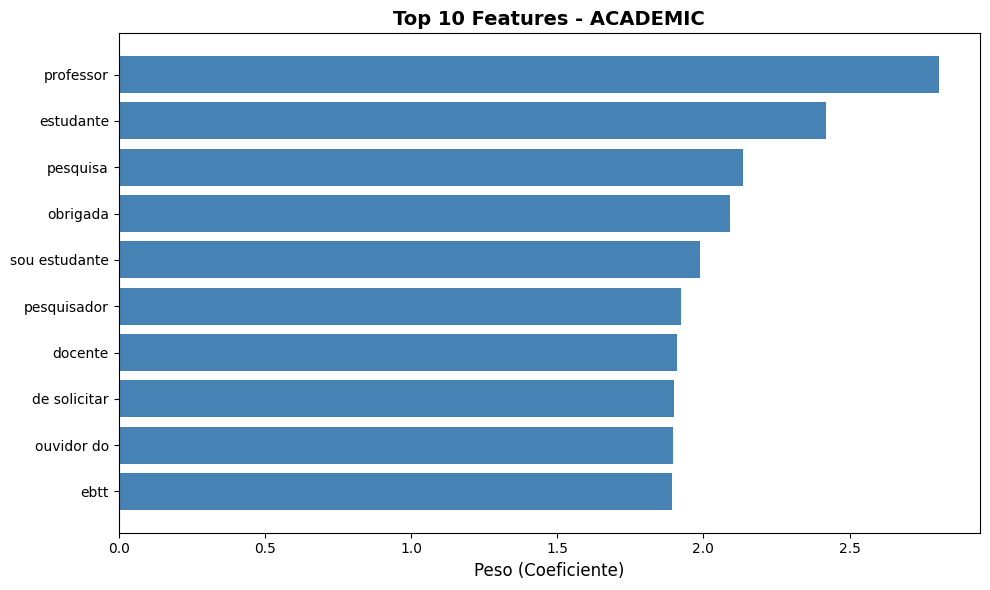


CLASSE: GOVERNMENT

Top 10 Features que favorecem government:
          feature   weight
   redistribuição 3.645256
         servidor 2.458742
         mestrado 2.414919
solicito informar 2.394402
         solicito 2.319859
       servidores 2.193422
  sua instituição 2.132384
              sou 2.098808
    sou servidora 2.012313
     dos técnicos 1.930791

✅ Figura salva: figuras/top10_features_government.png


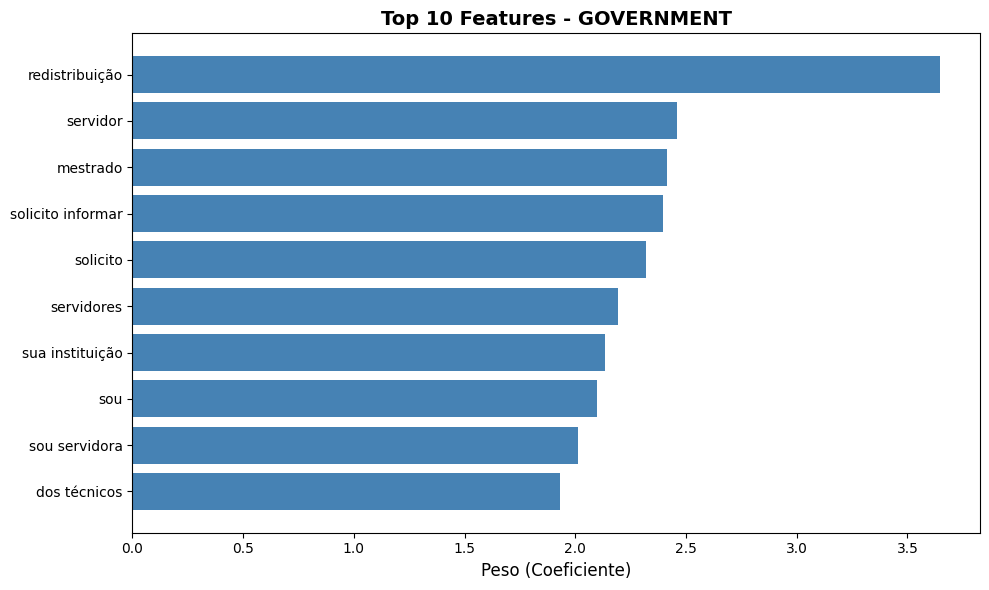


CLASSE: PRIVATE

Top 10 Features que favorecem private:
        feature   weight
            850 1.962076
        cliente 1.863180
          15414 1.778217
            oab 1.754058
     seguradora 1.653906
     normativos 1.645175
disponibilidade 1.644590
    trabalhista 1.587934
   prezados boa 1.586401
   não sigilosa 1.561952

✅ Figura salva: figuras/top10_features_private.png


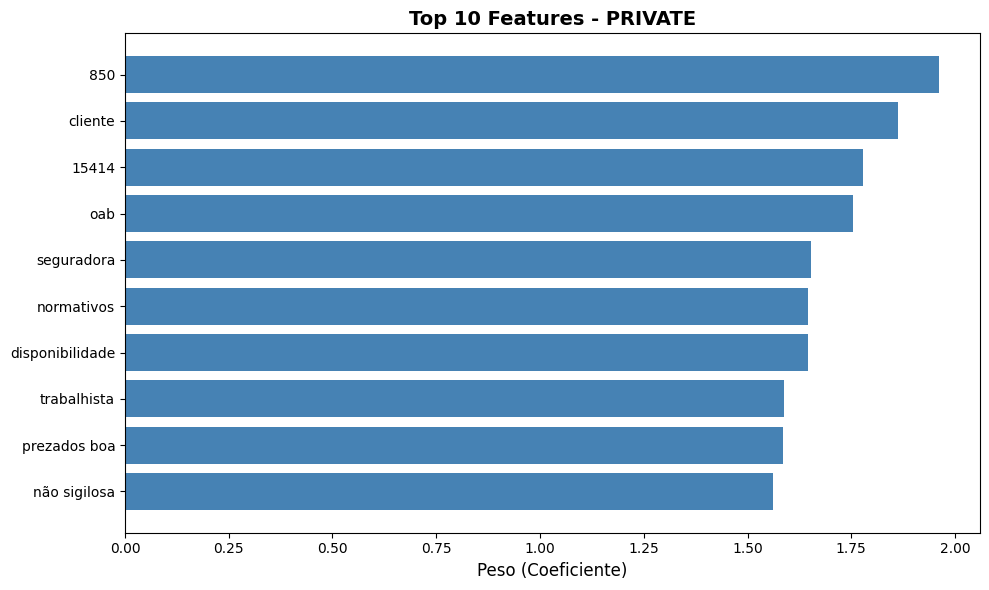


MATRIZ DE CONFUSÃO
✅ Figura salva: figuras/confusion_matrix_baseline.png


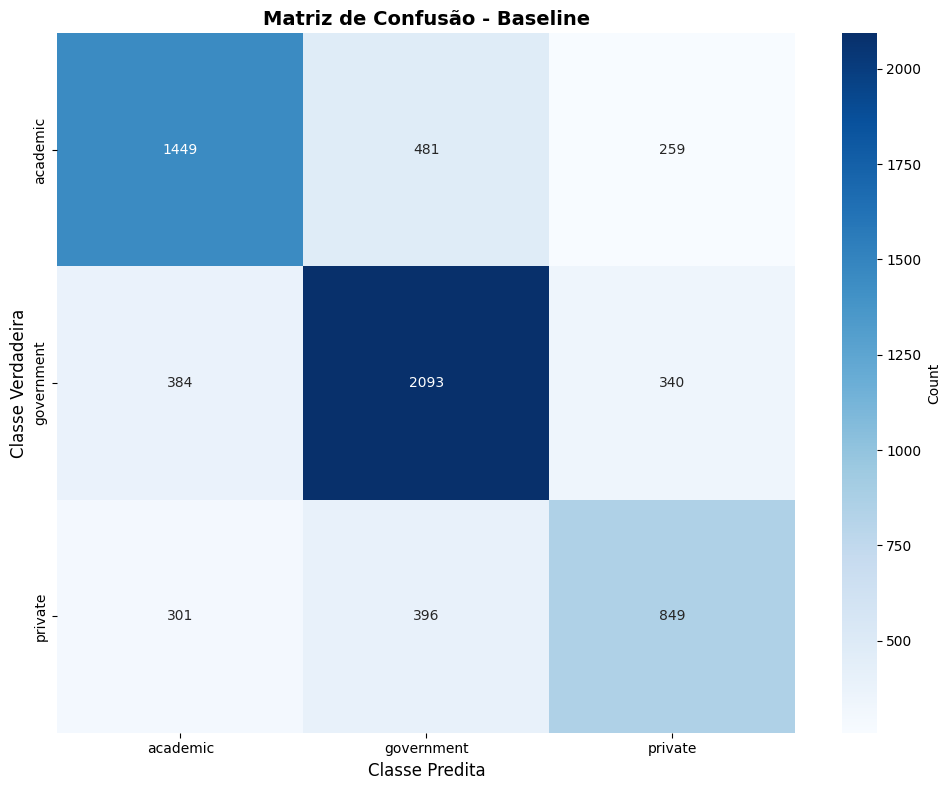


Matriz de Confusão:
            academic  government  private
academic        1449         481      259
government       384        2093      340
private          301         396      849

✅ ANÁLISE DE FEATURES CONCLUÍDA


In [10]:
# ============================================================================
# ANÁLISE DE FEATURES IMPORTANTES - BASELINE (SIMPLIFICADA)
# ============================================================================

print("="*80)
print("ANÁLISE DE FEATURES IMPORTANTES - BASELINE")
print("="*80)

# Obter nomes das features (palavras/n-grams)
feature_names = baseline_results['vectorizer'].get_feature_names_out()

# Criar diretório para salvar figuras
figures_dir = "figuras"
os.makedirs(figures_dir, exist_ok=True)

# Análise de Top 10 Features por Classe
print("\n" + "-"*80)
print("TOP 10 FEATURES QUE FAVORECEM CADA CLASSE")
print("-"*80)

baseline_feature_analysis = {}

for class_idx, class_name in enumerate(label_encoder.classes_):
    print(f"\n{'='*60}")
    print(f"CLASSE: {class_name.upper()}")
    print(f"{'='*60}")
    
    # Obter coeficientes da classe
    coef = baseline_results['classifier'].coef_[class_idx]
    
    # Criar DataFrame com features e pesos
    features_df = pd.DataFrame({
        'feature': feature_names,
        'weight': coef
    })
    
    # Filtrar apenas features positivas (que favorecem a classe)
    positive_features = features_df[features_df['weight'] > 0].copy()
    
    # Ordenar por peso (maior primeiro)
    top_10 = positive_features.nlargest(10, 'weight')
    
    # Armazenar
    baseline_feature_analysis[class_name] = {
        'top_10_positive': top_10
    }
    
    # Mostrar resultados
    print(f"\nTop 10 Features que favorecem {class_name}:")
    print(top_10[['feature', 'weight']].to_string(index=False))
    
    # Criar e salvar figura
    plt.figure(figsize=(10, 6))
    plt.barh(range(len(top_10)), top_10['weight'].values, color='steelblue')
    plt.yticks(range(len(top_10)), top_10['feature'].values, fontsize=10)
    plt.xlabel('Peso (Coeficiente)', fontsize=12)
    plt.title(f'Top 10 Features - {class_name.upper()}', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    
    # Salvar figura
    figure_path = os.path.join(figures_dir, f'top10_features_{class_name}.png')
    plt.savefig(figure_path, dpi=300, bbox_inches='tight')
    print(f"\n✅ Figura salva: {figure_path}")
    plt.show()

# Matriz de Confusão
print(f"\n{'='*80}")
print("MATRIZ DE CONFUSÃO")
print(f"{'='*80}")

cm = confusion_matrix(y_test, baseline_y_pred)
cm_df = pd.DataFrame(
    cm,
    index=label_encoder.classes_,
    columns=label_encoder.classes_
)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Count'})
plt.title('Matriz de Confusão - Baseline', fontsize=14, fontweight='bold')
plt.ylabel('Classe Verdadeira', fontsize=12)
plt.xlabel('Classe Predita', fontsize=12)
plt.tight_layout()

# Salvar matriz de confusão
confusion_path = os.path.join(figures_dir, 'confusion_matrix_baseline.png')
plt.savefig(confusion_path, dpi=300, bbox_inches='tight')
print(f"✅ Figura salva: {confusion_path}")
plt.show()

print("\nMatriz de Confusão:")
print(cm_df)

# Armazenar análise
baseline_results['feature_analysis'] = baseline_feature_analysis
baseline_results['confusion_matrix'] = cm_df

print(f"\n{'='*80}")
print("✅ ANÁLISE DE FEATURES CONCLUÍDA")
print(f"{'='*80}")


In [ ]:
# ============================================================================
# IMPORTS PARA MLP E BERT
# ============================================================================

# TensorFlow/Keras para MLP
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier

# Transformers para BERT
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from datasets import Dataset
import torch
from sklearn.model_selection import ParameterGrid
from sklearn.preprocessing import LabelBinarizer

# Configuração GPU
print("="*80)
print("CONFIGURAÇÃO DE GPU")
print("="*80)

# Verificar disponibilidade de GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ {len(gpus)} GPU(s) detectada(s):")
    for i, gpu in enumerate(gpus):
        print(f"   GPU {i}: {gpu.name}")
    
    # Configurar TensorFlow para usar GPU
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("   ✅ Memória dinâmica de GPU ativada")
    except RuntimeError as e:
        print(f"   ⚠️  Erro ao configurar GPU: {e}")
    
    # Configurar PyTorch para usar GPU
    if torch.cuda.is_available():
        print(f"✅ PyTorch detectou {torch.cuda.device_count()} GPU(s)")
        print(f"   GPU: {torch.cuda.get_device_name(0)}")
        device = torch.device("cuda")
    else:
        print("⚠️  PyTorch não detectou GPU")
        device = torch.device("cpu")
else:
    print("⚠️  Nenhuma GPU detectada. Usando CPU.")
    device = torch.device("cpu")

print(f"\n📊 Versões:")
print(f"   TensorFlow: {tf.__version__}")
print(f"   PyTorch: {torch.__version__}")
print("="*80)


In [ ]:
# ============================================================================
# CONFIGURAÇÃO MLP GRID-SEARCH
# ============================================================================

MLP_GRID_CONFIG = {
    'input_method': 'tfidf',
    'tfidf_params': {
        'max_features': [10000, 20000],
        'ngram_range': [(1, 2)]
    },
    'model_params': {
        'hidden_layers': [
            [(512, 256)],      # 2 camadas
            [(512, 256, 128)], # 3 camadas
            [(1024, 512, 256)] # 3 camadas maiores
        ],
        'dropout_rate': [0.3, 0.5],
        'learning_rate': [0.001, 0.0001],
        'batch_size': [32, 64]
    },
    'training_params': {
        'epochs': 50,
        'early_stopping_patience': 5,
        'validation_split': 0.15
    }
}

print("="*80)
print("CONFIGURAÇÃO MLP GRID-SEARCH")
print("="*80)
print(f"Max Features: {MLP_GRID_CONFIG['tfidf_params']['max_features']}")
print(f"N-gram Range: {MLP_GRID_CONFIG['tfidf_params']['ngram_range']}")
print(f"Hidden Layers: {MLP_GRID_CONFIG['model_params']['hidden_layers']}")
print(f"Dropout Rates: {MLP_GRID_CONFIG['model_params']['dropout_rate']}")
print(f"Learning Rates: {MLP_GRID_CONFIG['model_params']['learning_rate']}")
print(f"Batch Sizes: {MLP_GRID_CONFIG['model_params']['batch_size']}")
print(f"Epochs: {MLP_GRID_CONFIG['training_params']['epochs']}")
print("="*80)


In [ ]:
# ============================================================================
# MLP COM GRID-SEARCH
# ============================================================================

# Carregar dados
X_train = dataset["X_train"]
X_test = dataset["X_test"]
y_train = dataset["y_train"]
y_test = dataset["y_test"]
label_encoder = dataset["label_encoder"]

print("="*80)
print("MLP COM GRID-SEARCH")
print("="*80)

# Função para criar modelo MLP
def create_mlp_model(input_dim, hidden_layers, dropout_rate, learning_rate):
    """Cria modelo MLP com arquitetura configurável"""
    model = Sequential()
    
    # Primeira camada oculta
    model.add(Dense(hidden_layers[0], activation='relu', input_dim=input_dim))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    
    # Camadas ocultas adicionais
    for units in hidden_layers[1:]:
        model.add(Dense(units, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))
    
    # Camada de saída
    model.add(Dense(3, activation='softmax'))
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Wrapper para Grid-Search
def mlp_wrapper(input_dim, hidden_layers, dropout_rate, learning_rate, batch_size):
    """Wrapper para usar MLP com GridSearchCV"""
    def build_fn():
        return create_mlp_model(input_dim, hidden_layers, dropout_rate, learning_rate)
    
    model = KerasClassifier(
        build_fn=build_fn,
        batch_size=batch_size,
        epochs=MLP_GRID_CONFIG['training_params']['epochs'],
        verbose=0
    )
    
    return model

# Preparar dados (TF-IDF)
print(f"\n🔄 Preparando dados TF-IDF...")
vectorizer_mlp = TfidfVectorizer(
    max_features=10000,  # Será ajustado no grid
    ngram_range=(1, 2)    # Será ajustado no grid
)
X_train_mlp = vectorizer_mlp.fit_transform(X_train).toarray()
X_test_mlp = vectorizer_mlp.transform(X_test).toarray()

print(f"   ✅ Dados preparados: {X_train_mlp.shape} (treino), {X_test_mlp.shape} (teste)")

# Label encoding (one-hot)
print(f"\n🔄 Preparando labels (one-hot encoding)...")
lb = LabelBinarizer()
y_train_oh = lb.fit_transform(y_train)
y_test_oh = lb.transform(y_test)

print(f"   ✅ Labels preparados: {y_train_oh.shape} (treino), {y_test_oh.shape} (teste)")

# Grid-Search
print(f"\n{'='*80}")
print("INICIANDO GRID-SEARCH MLP")
print(f"{'='*80}")

# Criar grid de parâmetros
param_grid = {
    'hidden_layers': MLP_GRID_CONFIG['model_params']['hidden_layers'],
    'dropout_rate': MLP_GRID_CONFIG['model_params']['dropout_rate'],
    'learning_rate': MLP_GRID_CONFIG['model_params']['learning_rate'],
    'batch_size': MLP_GRID_CONFIG['model_params']['batch_size']
}

# Criar modelo base
mlp_model = mlp_wrapper(
    input_dim=X_train_mlp.shape[1],
    hidden_layers=[(512, 256)],
    dropout_rate=0.5,
    learning_rate=0.001,
    batch_size=32
)

# Grid-Search
print(f"\n🔄 Executando Grid-Search (pode demorar vários minutos)...")
print(f"   Total de combinações: {len(ParameterGrid(param_grid))}")

grid_search_mlp = GridSearchCV(
    estimator=mlp_model,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',  # Usar apenas acurácia
    n_jobs=1,  # Keras não suporta paralelismo
    verbose=1
)

grid_search_mlp.fit(X_train_mlp, y_train_oh)

print(f"\n✅ Grid-Search concluído!")

# Resultados
print(f"\n{'='*80}")
print("RESULTADOS - MLP GRID-SEARCH")
print(f"{'='*80}")
print(f"Melhor Score (CV): {grid_search_mlp.best_score_:.4f}")
print(f"\nMelhores Parâmetros:")
for param, value in grid_search_mlp.best_params_.items():
    print(f"   {param}: {value}")

# Avaliar no conjunto de teste
print(f"\n🔄 Avaliando melhor modelo no conjunto de teste...")
best_mlp = grid_search_mlp.best_estimator_
mlp_test_score = best_mlp.score(X_test_mlp, y_test_oh)
mlp_y_pred = best_mlp.predict(X_test_mlp)

# Converter predições de one-hot para labels
mlp_y_pred_labels = np.argmax(mlp_y_pred, axis=1) if mlp_y_pred.ndim > 1 else mlp_y_pred

print(f"\n📊 Resultados no Teste:")
print(f"   Test Accuracy: {mlp_test_score:.4f}")

# Armazenar resultados
mlp_results = {
    'model_name': 'MLP (Grid-Search)',
    'best_params': grid_search_mlp.best_params_,
    'best_cv_score': grid_search_mlp.best_score_,
    'test_score': mlp_test_score,
    'model': best_mlp,
    'vectorizer': vectorizer_mlp,
    'predictions': mlp_y_pred_labels,
    'grid_search': grid_search_mlp
}

print(f"\n{'='*80}")
print("✅ MLP GRID-SEARCH CONCLUÍDO")
print(f"{'='*80}")


In [ ]:
# ============================================================================
# CONFIGURAÇÃO BERT GRID-SEARCH
# ============================================================================

BERT_GRID_CONFIG = {
    'model_name': 'neuralmind/bert-base-portuguese-cased',  # BERTimbau
    'method': 'finetuning',
    'grid_params': {
        'learning_rate': [2e-5, 3e-5, 5e-5],
        'batch_size': [8, 16],
        'num_train_epochs': [2, 3],
        'weight_decay': [0.01, 0.1],
        'max_length': [256, 512]
    },
    'fixed_params': {
        'warmup_steps': 500,
        'evaluation_strategy': 'epoch',
        'save_strategy': 'epoch',
        'load_best_model_at_end': True,
        'metric_for_best_model': 'accuracy'
    }
}

print("="*80)
print("CONFIGURAÇÃO BERT GRID-SEARCH")
print("="*80)
print(f"Model: {BERT_GRID_CONFIG['model_name']}")
print(f"Learning Rates: {BERT_GRID_CONFIG['grid_params']['learning_rate']}")
print(f"Batch Sizes: {BERT_GRID_CONFIG['grid_params']['batch_size']}")
print(f"Epochs: {BERT_GRID_CONFIG['grid_params']['num_train_epochs']}")
print(f"Weight Decay: {BERT_GRID_CONFIG['grid_params']['weight_decay']}")
print(f"Max Length: {BERT_GRID_CONFIG['grid_params']['max_length']}")
print(f"Total de combinações: {len(ParameterGrid(BERT_GRID_CONFIG['grid_params']))}")
print("="*80)


In [ ]:
# ============================================================================
# BERT COM GRID-SEARCH
# ============================================================================

# Carregar dados
X_train = dataset["X_train"]
X_test = dataset["X_test"]
y_train = dataset["y_train"]
y_test = dataset["y_test"]
label_encoder = dataset["label_encoder"]

print("="*80)
print("BERT COM GRID-SEARCH")
print("="*80)

# Função para preparar dataset
def prepare_bert_dataset(texts, labels, tokenizer, max_length=512):
    """Prepara dataset para BERT"""
    def tokenize_function(examples):
        return tokenizer(
            examples['text'],
            truncation=True,
            padding='max_length',
            max_length=max_length
        )
    
    dataset_dict = {
        'text': texts.tolist() if isinstance(texts, np.ndarray) else texts,
        'labels': labels.tolist() if isinstance(labels, np.ndarray) else labels
    }
    
    dataset = Dataset.from_dict(dataset_dict)
    tokenized_dataset = dataset.map(tokenize_function, batched=True)
    
    return tokenized_dataset

# Função de métricas
def compute_metrics(eval_pred):
    """Calcula métricas para BERT (apenas acurácia)"""
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return {
        'accuracy': accuracy_score(labels, predictions)
    }

# Função para treinar BERT com parâmetros específicos
def train_bert_with_params(X_train, X_test, y_train, y_test, params):
    """Treina BERT com parâmetros específicos"""
    print(f"\n{'='*60}")
    print(f"Testando: {params}")
    print(f"{'='*60}")
    
    # Carregar modelo e tokenizer
    tokenizer = AutoTokenizer.from_pretrained(BERT_GRID_CONFIG['model_name'])
    model = AutoModelForSequenceClassification.from_pretrained(
        BERT_GRID_CONFIG['model_name'],
        num_labels=3
    )
    
    # Preparar datasets
    train_dataset = prepare_bert_dataset(
        X_train, y_train, tokenizer, params['max_length']
    )
    test_dataset = prepare_bert_dataset(
        X_test, y_test, tokenizer, params['max_length']
    )
    
    # Training arguments
    output_dir = f'./bert_results_{hash(str(params))}'
    training_args = TrainingArguments(
        output_dir=output_dir,
        learning_rate=params['learning_rate'],
        per_device_train_batch_size=params['batch_size'],
        per_device_eval_batch_size=params['batch_size'],
        num_train_epochs=params['num_train_epochs'],
        weight_decay=params['weight_decay'],
        warmup_steps=BERT_GRID_CONFIG['fixed_params']['warmup_steps'],
        evaluation_strategy=BERT_GRID_CONFIG['fixed_params']['evaluation_strategy'],
        save_strategy=BERT_GRID_CONFIG['fixed_params']['save_strategy'],
        load_best_model_at_end=BERT_GRID_CONFIG['fixed_params']['load_best_model_at_end'],
        metric_for_best_model=BERT_GRID_CONFIG['fixed_params']['metric_for_best_model'],
        logging_dir=f'{output_dir}/logs',
        logging_steps=100,
        save_total_limit=1,
        fp16=torch.cuda.is_available(),  # Usar mixed precision se GPU disponível
        report_to='none'  # Não reportar para wandb/tensorboard
    )
    
    # Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        compute_metrics=compute_metrics
    )
    
    # Treinar
    print(f"🔄 Treinando...")
    trainer.train()
    
    # Avaliar
    print(f"🔄 Avaliando...")
    eval_results = trainer.evaluate()
    
    # Limpar diretório temporário
    import shutil
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)
    
    return {
        'params': params,
        'model': model,
        'tokenizer': tokenizer,
        'trainer': trainer,
        'eval_results': eval_results,
        'test_score': eval_results['eval_accuracy']
    }

# Grid-Search manual
print(f"\n{'='*80}")
print("INICIANDO GRID-SEARCH BERT")
print(f"{'='*80}")

param_grid = ParameterGrid(BERT_GRID_CONFIG['grid_params'])
bert_results = []
total_combinations = len(param_grid)

print(f"\n📊 Total de combinações: {total_combinations}")
print(f"⏱️  Estimativa: ~{total_combinations * 30} minutos (dependendo da GPU)")

for idx, params in enumerate(param_grid, 1):
    print(f"\n{'='*80}")
    print(f"Combinação {idx}/{total_combinations}")
    print(f"{'='*80}")
    
    try:
        result = train_bert_with_params(X_train, X_test, y_train, y_test, params)
        bert_results.append(result)
        
        print(f"✅ Test Accuracy: {result['test_score']:.4f}")
    except Exception as e:
        print(f"❌ Erro ao treinar: {e}")
        continue

# Melhor modelo
if bert_results:
    best_bert = max(bert_results, key=lambda x: x['test_score'])
    
    print(f"\n{'='*80}")
    print("RESULTADOS - BERT GRID-SEARCH")
    print(f"{'='*80}")
    print(f"Melhor modelo BERT:")
    print(f"  Parâmetros: {best_bert['params']}")
    print(f"  Test Accuracy: {best_bert['test_score']:.4f}")
    print(f"{'='*80}")
    
    # Armazenar resultados
    bert_final_results = {
        'model_name': 'BERT (Grid-Search)',
        'best_params': best_bert['params'],
        'test_score': best_bert['test_score'],
        'model': best_bert['model'],
        'tokenizer': best_bert['tokenizer'],
        'all_results': bert_results
    }
else:
    print(f"\n❌ Nenhum modelo BERT foi treinado com sucesso.")
    bert_final_results = None

print(f"\n{'='*80}")
print("✅ BERT GRID-SEARCH CONCLUÍDO")
print(f"{'='*80}")


In [ ]:
# ============================================================================
# COMPARAÇÃO DE RESULTADOS
# ============================================================================

print("="*80)
print("COMPARAÇÃO DE RESULTADOS")
print("="*80)

# Preparar dados para comparação
comparison_data = {
    'Modelo': [],
    'Test Accuracy': []
}

# Adicionar coluna de CV Accuracy se disponível no baseline
if 'cv_mean' in baseline_results:
    comparison_data['CV Accuracy (10 folds)'] = []

# Baseline
comparison_data['Modelo'].append('Baseline (TF-IDF + Logistic Regression)')
comparison_data['Test Accuracy'].append(baseline_results['test_score'])
if 'cv_mean' in baseline_results:
    comparison_data['CV Accuracy (10 folds)'].append(
        f"{baseline_results['cv_mean']:.4f} ± {baseline_results['cv_std']:.4f}"
    )

# MLP
if 'mlp_results' in globals():
    comparison_data['Modelo'].append('MLP (Grid-Search)')
    comparison_data['Test Accuracy'].append(mlp_results['test_score'])
    if 'cv_mean' in baseline_results:
        comparison_data['CV Accuracy (10 folds)'].append(
            f"{mlp_results['best_cv_score']:.4f}"
        )

# BERT
if 'bert_final_results' in globals() and bert_final_results is not None:
    comparison_data['Modelo'].append('BERT (Grid-Search)')
    comparison_data['Test Accuracy'].append(bert_final_results['test_score'])
    if 'cv_mean' in baseline_results:
        comparison_data['CV Accuracy (10 folds)'].append('N/A')

# Criar DataFrame
comparison_df = pd.DataFrame(comparison_data)
print("\n📊 TABELA COMPARATIVA:")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

# Visualização
print(f"\n{'='*80}")
print("VISUALIZAÇÃO COMPARATIVA")
print(f"{'='*80}")

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_df))
width = 0.35

bars = ax.bar(x, comparison_df['Test Accuracy'], width, label='Test Accuracy', color='steelblue')

ax.set_xlabel('Modelo', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Comparação de Modelos - Test Accuracy', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Modelo'], rotation=15, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for i, (bar, acc) in enumerate(zip(bars, comparison_df['Test Accuracy'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.4f}',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()

# Salvar figura
comparison_path = os.path.join(figures_dir, 'model_comparison.png')
plt.savefig(comparison_path, dpi=300, bbox_inches='tight')
print(f"✅ Figura salva: {comparison_path}")
plt.show()

# Análise
print(f"\n{'='*80}")
print("ANÁLISE")
print(f"{'='*80}")

best_model_idx = comparison_df['Test Accuracy'].idxmax()
best_model = comparison_df.loc[best_model_idx, 'Modelo']
best_score = comparison_df.loc[best_model_idx, 'Test Accuracy']

print(f"🏆 Melhor Modelo: {best_model}")
print(f"   Test Accuracy: {best_score:.4f}")

print(f"\n📈 Melhoria em relação ao Baseline:")
baseline_acc = comparison_df.loc[0, 'Test Accuracy']
improvement = ((best_score - baseline_acc) / baseline_acc) * 100
print(f"   Baseline: {baseline_acc:.4f}")
print(f"   Melhor: {best_score:.4f}")
print(f"   Melhoria: {improvement:+.2f}%")

print(f"\n{'='*80}")
print("✅ COMPARAÇÃO CONCLUÍDA")
print(f"{'='*80}")
